# FX と暗号資産: 取引所セッションのない24時間データ

株式向けの道具立てはセッションに寄りかかっています。取引所が「1日」を定義し、寄りと引けを
決める。FX と暗号資産にはそれがありません。EURUSD は週末の停止を挟みつつ24時間動き、BTC は
止まりません。そして「日次終値」はデスクの*取り決め*です（ニューヨーク17時？ 東京カット？
UTC の深夜？）。このレシピでは、その世界のための h5i-db の道具を見ます。セッションの見方を
作る IANA タイムゾーン引数付きの `time_bucket`、24時間ローリングのボラのための行ベースの
ウィンドウ、そして閑散な時間帯をまたぐ規則的な格子のための `gapfill` です。

**データについて正直に言っておくと**、合成のティック生成器は一様な到着を出すだけで、
東京／ロンドン／ニューヨークの流動性の時計も、週末の停止も持っていません。そこで FX の週末は
明示的にモデル化し（FX ペアについて金曜21:00 から日曜21:00 UTC のティックを除き、BTC は
そのまま流します）、実データなら構造が見えるはずの場所を以下で明記します。

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa

import h5i_db
from h5i_db import col, count_star, sql_expr, time_bucket
import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("prod_fx"), create=True)

# 96 hours starting Friday 2026-06-05 00:00 UTC -> covers a full weekend.
raw = cu.make_fx_ticks(pairs=["EURUSD", "USDJPY", "BTCUSD"], hours=96, start="2026-06-05").to_pandas()

wk_open = pd.Timestamp("2026-06-05 21:00", tz="UTC")   # Fri 5pm ET
wk_close = pd.Timestamp("2026-06-07 21:00", tz="UTC")  # Sun 5pm ET
is_weekend = (raw["ts"] >= wk_open) & (raw["ts"] < wk_close)
ticks_df = raw[~(is_weekend & (raw["pair"] != "BTCUSD"))].reset_index(drop=True)
print(f"{len(raw):,} generated ticks -> {len(ticks_df):,} after removing the FX weekend")

864,000 generated ticks -> 575,395 after removing the FX weekend


## 1. ティックを保存する

3つの銘柄を1つの `ticks` テーブルに入れます。FX の週末は日ごとの件数の穴として現れ、その
あいだも BTC は印字し続けます。マルチアセットの帳簿が付き合わされる非対称そのものです。

In [2]:
schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("pair", pa.string()),
        pa.field("bid", pa.float64()),
        pa.field("ask", pa.float64()),
    ]
)
db.create_table("ticks", schema, time_column="ts", sort_key=["ts", "pair"])
db.append("ticks", pa.Table.from_pandas(ticks_df, schema=schema, preserve_index=False),
          note="4 days of FX/crypto ticks, FX weekend removed")

MID = (col("bid") + col("ask")) / 2

(
    db.table("ticks")
    .group_by(time_bucket("1d", col("ts")).alias("day_utc"), "pair")
    .agg(ticks=count_star())
    .sort(["day_utc", "pair"])
    .to_pandas()
).pivot(index="day_utc", columns="pair", values="ticks")

pair,BTCUSD,EURUSD,USDJPY
day_utc,,,
2026-06-05 00:00:00+00:00,72361.0,62877.0,62682.0
2026-06-06 00:00:00+00:00,71820.0,NaN,NaN
2026-06-07 00:00:00+00:00,71995.0,8956.0,8987.0
2026-06-08 00:00:00+00:00,71824.0,71794.0,72099.0


## 2. 「1日」とは何か: 同じティックからの3つの答え

`time_bucket('1d', ts, tz)` は日の境界を、任意の IANA タイムゾーンの*現地の深夜*に揃えます。
夏時間も面倒を見てくれます。同じティックの流れから、UTC、東京、ニューヨークの取り決めごとに
違う日次終値が出ます。24時間のフローを切る瞬間が、それぞれ違うからです。（FX でよく使われる
「ニューヨーク17時」のカットは深夜ではなく現地17:00 です。その取り決めが必要なら、
`time_bucket` の任意の起点引数で境界をずらせます。）

In [3]:
def daily_close(timezone, label: str) -> pd.DataFrame:
    out = (
        db.table("ticks")
        .filter(col("pair") == "EURUSD")
        .group_by(time_bucket("1d", col("ts"), timezone=timezone).alias("bucket"))
        .agg(close=MID.last("ts"))
        .sort("bucket")
        .to_pandas()
    )
    out[label + "_boundary_utc"] = out["bucket"].dt.strftime("%m-%d %H:%M")
    return out.rename(columns={"close": label})[[label + "_boundary_utc", label]]


utc = daily_close(None, "close_utc")
tokyo = daily_close("Asia/Tokyo", "close_tokyo")
ny = daily_close("America/New_York", "close_ny")
pd.concat([utc, tokyo, ny], axis=1).round(5)

,close_utc_boundary_utc,close_utc,close_tokyo_boundary_utc,close_tokyo,close_ny_boundary_utc,close_ny
0,06-05 00:00,1.09531,06-04 15:00,1.09472,06-04 04:00,1.08267
1,06-07 00:00,1.10249,06-05 15:00,1.09531,06-05 04:00,1.09531
2,06-08 00:00,1.12921,06-07 15:00,1.10696,06-07 04:00,1.10811
3,NaN,NaN,06-08 15:00,1.12921,06-08 04:00,1.12921


どの取り決めも、日の始まりが違う UTC の瞬間になります（00:00、東京の深夜なら15:00、夏時間の
ニューヨークの深夜なら04:00）。だから「同じ日」の終値が列ごとに違います。実際のデスクでは
これは細かい話ではありません。日次損益も VaR の窓もキャリーの発生も、選んだカットをそのまま
受け継ぎます。

## 3. 1時間足を保存して、そこから24時間ローリングの実現ボラ

1時間ごとのミッドの足を、それ自体のテーブルに保存します。h5i-db では派生テーブルは安く
（コミット1回です）、下流のクエリ――ローリングウィンドウ、gapfill――は*保存された*規則的な
系列の上で動きたがるからです。24時間ローリングのボラは行ベースのウィンドウ
（`ROWS BETWEEN 23 PRECEDING`）です。どの時間も存在する24時間データにとって自然な枠です。
ただし FX の週末について注意点が1つ。欠けた時間はそもそも行として存在しないので、ウィンドウは
黙って穴をまたぎます。月曜の最初の足では、金曜の時間が「直近24時間」に混ざります。それが問題に
なるなら、規則的な格子（セクション5）が対処になります。

In [4]:
bars = (
    db.table("ticks")
    .group_by(time_bucket("1h", col("ts")).alias("hr"), "pair")
    .agg(mid_close=MID.last("ts"), avg_spread=(col("ask") - col("bid")).mean(), ticks=count_star())
    .select(col("hr").alias("ts"), "pair", "mid_close", "avg_spread", "ticks")
    .sort(["ts", "pair"])
    .to_arrow()
)

bars_schema = pa.schema(
    [pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False)]
    + [bars.schema.field(i) for i in range(1, bars.num_columns)]
)
db.create_table("bars_1h", bars_schema, time_column="ts", sort_key=["ts", "pair"])
db.append("bars_1h", bars.cast(bars_schema), note="hourly mid bars")

PREV_MID = sql_expr("lag(mid_close)").over(partition_by="pair", order_by="ts")

rv = (
    db.table("bars_1h")
    .with_columns(lr=(col("mid_close") / PREV_MID).log())
    .select(
        "ts", "pair",
        rv_ann=(
            (col("lr") * col("lr")).rolling_sum(24, order_by="ts", partition_by="pair") * 365.0
        ).sqrt(),
    )
    .sort(["ts", "pair"])
    .to_pandas()
).dropna()
rv.tail(3)

,ts,pair,rv_ann
189,2026-06-08 23:00:00+00:00,BTCUSD,0.271188
190,2026-06-08 23:00:00+00:00,EURUSD,0.286058
191,2026-06-08 23:00:00+00:00,USDJPY,0.276358


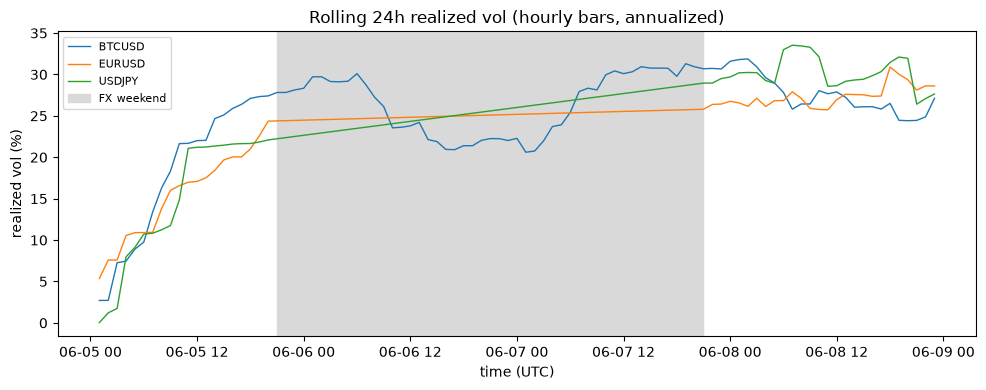

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
for pair, g in rv.groupby("pair"):
    ax.plot(g["ts"], 100 * g["rv_ann"], lw=1.0, label=pair)
ax.axvspan(wk_open, wk_close, color="0.85", zorder=0, label="FX weekend")
ax.set_title("Rolling 24h realized vol (hourly bars, annualized)")
ax.set_xlabel("time (UTC)")
ax.set_ylabel("realized vol (%)")
ax.legend(fontsize=8)
fig.tight_layout()

## 4. 流動性の時計 — 合成データでは手法を、実データでは構造を

24時間の1週間にもリズムはあります。東京の朝、FX のスプレッドがいちばん締まるロンドンと
ニューヨークの重なり（おおむね12:00〜16:00 UTC）、そしてニューヨーク後の凪。クエリはティックと
スプレッドを時刻でバケットするだけで、時刻を各取引拠点の現地時間に直すのは pandas の
`tz_convert` 1つです。**以下の線は平坦になるはずです**。一様な合成到着に時計はありません。
実際のフィードデータなら、このまったく同じクエリがU字と重なりの山を描きます。持ち帰るべきは
この絵ではなく、手法のほうです。

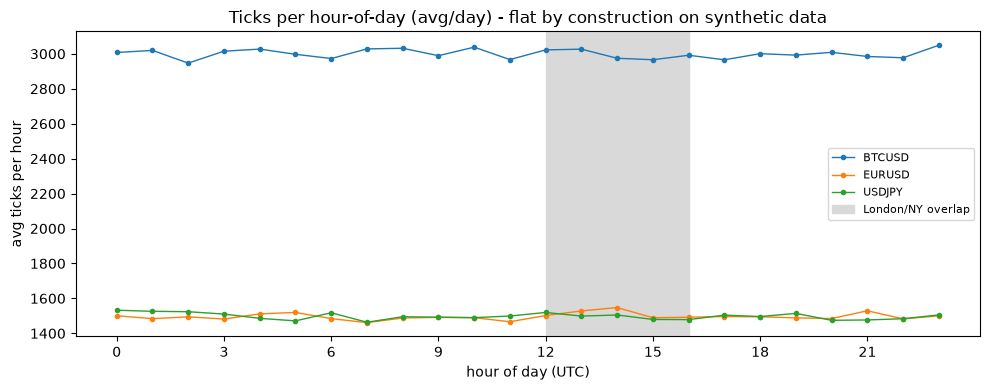

In [6]:
clock = (
    db.table("ticks")
    .group_by(sql_expr("extract(hour FROM ts)").alias("hour_utc"), "pair")
    .agg(ticks=count_star(), avg_spread=(col("ask") - col("bid")).mean())
    .sort(["hour_utc", "pair"])
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(10, 4))
for pair, g in clock.groupby("pair"):
    ax.plot(g["hour_utc"], g["ticks"] / 4.0, lw=1.0, marker="o", ms=3, label=pair)
ax.axvspan(12, 16, color="0.85", zorder=0, label="London/NY overlap")
ax.set_title("Ticks per hour-of-day (avg/day) - flat by construction on synthetic data")
ax.set_xlabel("hour of day (UTC)")
ax.set_ylabel("avg ticks per hour")
ax.set_xticks(range(0, 24, 3))
ax.legend(fontsize=8)
fig.tight_layout()

## 5. `gapfill` による規則的な格子と、幻のリターンの罠

`gapfill(table, time_col, step, mode)` は*保存された*テーブルを規則的な格子上に標本化します。
腹に入れておくことが3つあります。

- **刻みは生の時刻単位**です。`timestamp[us]` 列ならマイクロ秒で、`1_000_000` が1秒格子、
  `60_000_000` が1分格子です。生成される格子は100万行で頭打ちなので、対象期間に合う刻みを
  選んでください。
- gapfill は**キーごとのグループ化を持たない**素の格子標本器です。複数銘柄のテーブルに
  かけると、`locf` は*最後にティックが来たペアが何であれ*それを持ち越します。必ず単一系列の
  テーブルに対して gapfill してください。だからここでは EURUSD のティックを先に独立して
  保存します。
- `'null'` モードが値を出すのは、観測が格子の瞬間とちょうど一致したときだけです。不規則な
  ティックではまず起きないので、標本化には `'locf'`（か `'interpolate'`）を使い、「実際に
  売買された分だけ」が欲しいときは素の `time_bucket` の足を使ってください。

In [7]:
eur = ticks_df[ticks_df["pair"] == "EURUSD"]
db.create_table("eur_ticks", schema, time_column="ts", sort_key=["ts", "pair"])
db.append("eur_ticks", pa.Table.from_pandas(eur, schema=schema, preserve_index=False),
          note="EURUSD only, for gapfill")

# A research-grade 1-second grid: step = 1_000_000 us.
n_1s = db.sql("SELECT count(*) AS n FROM gapfill('eur_ticks', 'ts', 1000000, 'locf')").to_pandas()["n"][0]
print(f"1s locf grid over 96h: {n_1s:,} rows (cap is 1M - a 1s grid fits ~11 days)")

# A 1-minute locf grid, plus honest 1m bars (only minutes that actually traded):
grid_locf = db.sql("SELECT ts, bid, ask FROM gapfill('eur_ticks', 'ts', 60000000, 'locf')").to_pandas()
grid_locf["mid"] = (grid_locf["bid"] + grid_locf["ask"]) / 2
bars_1m = (
    db.table("eur_ticks")
    .group_by(time_bucket("1m", col("ts")).alias("minute"))
    .agg(mid=MID.last("ts"))
    .sort("minute")
    .to_pandas()
)
print(f"1m locf grid: {len(grid_locf):,} rows; traded minutes: {len(bars_1m):,}; "
      f"fabricated by locf: {len(grid_locf) - len(bars_1m):,}")

1s locf grid over 96h: 345,599 rows (cap is 1M - a 1s grid fits ~11 days)
1m locf grid: 5,760 rows; traded minutes: 2,880; fabricated by locf: 2,880


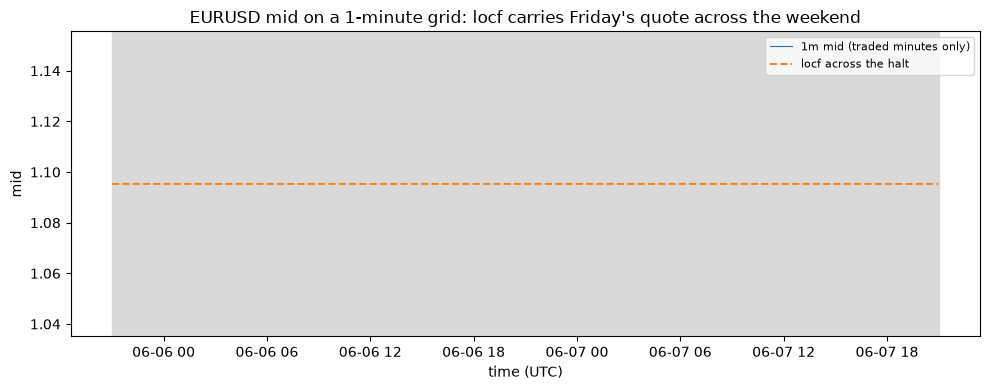

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_bars = bars_1m.set_index("minute")["mid"].reindex(grid_locf["ts"])  # NaN = untraded minute
ax.plot(grid_locf["ts"], plot_bars.values, lw=0.8, label="1m mid (traded minutes only)")
wk = grid_locf[(grid_locf["ts"] >= wk_open) & (grid_locf["ts"] < wk_close)]
ax.plot(wk["ts"], wk["mid"], lw=1.4, ls="--", label="locf across the halt")
ax.axvspan(wk_open, wk_close, color="0.85", zorder=0)
ax.set_title("EURUSD mid on a 1-minute grid: locf carries Friday's quote across the weekend")
ax.set_xlabel("time (UTC)")
ax.set_ylabel("mid")
ax.legend(fontsize=8)
fig.tight_layout()

破線の区間は*でっち上げられた*平坦線です。`locf` とはそういう意味です。帳簿を評価するには
正しい選択で（最後の気配**こそが**手元の最良の知識です）、リターンの統計にとっては間違った
入力です。2,880個のゼロリターンが測定されるボラを押し下げますし、週末の値動き全体が再開時の
偽の1分足1本に落ちます（この引きでは控えめですが、荒れた週末のあとなら断然いちばん大きな
「1分」リターンになります）。

In [9]:
ret_locf = np.log(grid_locf["mid"]).diff().dropna()
ret_traded = np.log(bars_1m["mid"]).diff().dropna()  # untraded minutes never enter

ann = np.sqrt(365 * 24 * 60)
pd.DataFrame(
    {
        "series": ["locf grid", "traded minutes only"],
        "n_returns": [len(ret_locf), len(ret_traded)],
        "ann_vol_pct": [100 * ret_locf.std() * ann, 100 * ret_traded.std() * ann],
        "max_abs_1m_ret_bp": [1e4 * ret_locf.abs().max(), 1e4 * ret_traded.abs().max()],
    }
).round(2)

,series,n_returns,ann_vol_pct,max_abs_1m_ret_bp
0,locf grid,5759,18.64,33.95
1,traded minutes only,2879,26.46,35.86


ゼロリターンの詰め物が測定ボラを3分の1削り、週末のギャップが合成された1分に圧縮されます。
売買された分だけの系列――ティックがある場所にしか存在しない、素の `time_bucket` の足――が、
ボラ推定にとって誠実な入力です。

## まとめ

- 24時間データでは「1日」は事実ではなくパラメータです。`time_bucket('1d', ts, '<IANA tz>')` が
  どの取り決めについてもセッションに揃った日を、夏時間込みで作ります。同じティックから、
  違う日次終値が出ます。
- 行ベースのウィンドウ（`ROWS BETWEEN 23 PRECEDING`）は連続データにとって自然なローリングの
  枠ですが、データの*穴*を黙ってまたぎます。自分の市場の停止時間を把握してください。
- `gapfill` には保存済みの単一系列テーブルが要ります。刻みは生のマイクロ秒（`1_000_000` ＝
  1秒）で、格子は100万行が上限です。
- `locf` は評価のため、売買された分の足は測定のためです。停止をまたいで気配を持ち越すと、
  ゼロリターンがでっち上げられ（ボラが下振れ）、幻のギャップ1本が加わります（裾が上振れ）。
- 合成ティックに流動性の時計はありません。ここでの時刻別クエリは、実際のフィードに対して
  走らせるべき手法です。そちらでは東京／ロンドン／ニューヨークの構造がちゃんと現れます。

In [10]:
db.close()